# Oil Spill - Point release with stranding in the Barents Sea

Example for running a single ocean model with online oil spill simulation outside of North Cape with a continuous point release in the Barents sea.


In [1]:
# Load required modules
%matplotlib inline

from IPython.display import display

import numpy as np
import datetime
from importlib import reload

#For plotting
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

plt.rcParams["animation.html"] = "jshtml"
mpl.rcParams['figure.facecolor'] = 'white'

# Import relevant modules from within GPU Ocean
from gpuocean.SWEsimulators import GPUOceanSim
from gpuocean.utils import IPythonMagic, NetCDFInitialization, DrifterPlotHelper
from gpuocean.drifters import LagrangianUtils

from gpuocean.oilspill import OilDrift
from gpuocean.oilspill import OilSpillPlotHelper as osph

In [2]:
# Create the GPU context
%cuda_context_handler gpu_ctx

## Read initial conditions and forcing from operational ocean forecast

We choose a subdomain of the Barents Sea located just outside of the North Cape, using a day that has wind blowing towards land.


In [3]:
# Url or path to operational ocean forecast
# Wind towards land
source_url = 'https://thredds.met.no/thredds/dodsC/fou-hi/norkyst800m-1h/NorKyst-800m_ZDEPTHS_his.an.2024052000.nc'


# Use a predefined subdomain
casename = 'north_cape'

reload(NetCDFInitialization)
T_end_hours = 23 

# Load initial and boundary conditions, bathymetry, landmask, forcing, etc
sim_args = NetCDFInitialization.getInitialConditionsNorKystCases(source_url, casename, timestep_indices=list(range(T_end_hours+1)),
                                                                 fill_wind=True, fill_interpolator_linear=False)

## Define the spill location and plot area

We let the oil spill take place at an arbitrary location a bit east of North Cape where there are strong currents.

In [4]:
# Cell ID of release:
cell_id_x = 118
cell_id_y = 118

# We put the release in the middle of this cell, using 
# the internal (x, y) locations within the Cartesian grid:
x0 = sim_args["dx"]*(cell_id_x + 0.5)
y0 = sim_args["dx"]*(cell_id_y + 0.5)

print("Release location: ", (sim_args["lat"][cell_id_y+2, cell_id_x+2], sim_args["lon"][cell_id_y+2, cell_id_x+2]))

Release location:  (71.10497096819562, 23.84151353899916)


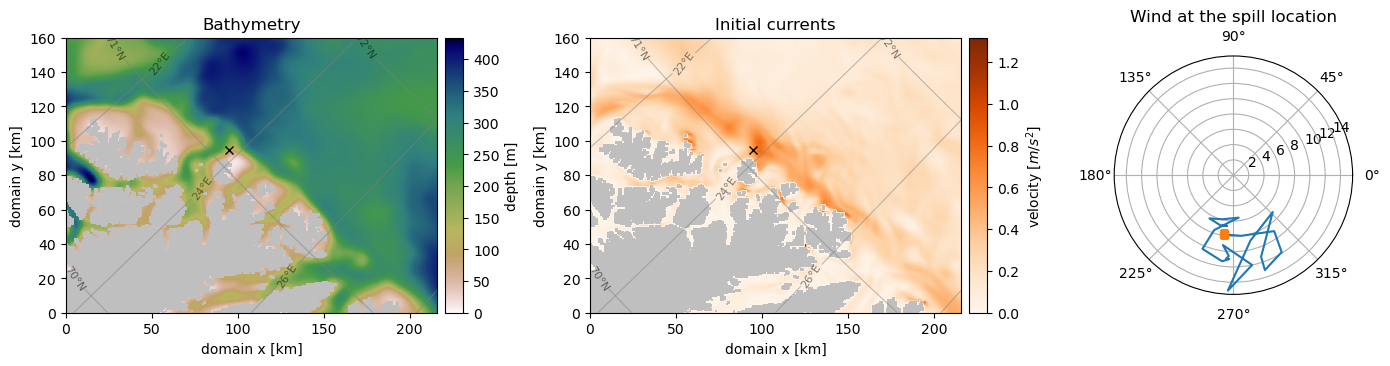

In [5]:
# Visualize the area with depth, initial velocities, and wind evoluation at the spill location

fig = plt.figure(figsize=(14, 5))

gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.6])

# Create subplots using GridSpec
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2], projection='polar')

ax1 = DrifterPlotHelper.background_from_sim_args(sim_args, ax=ax1, lonlat_diff=[2, 1], background_type="depth", cmap=plt.cm.gist_earth_r)
ax1.plot(x0/1000, y0/1000, "kx")
ax1.set_xlabel("domain x [km]")
ax1.set_ylabel("domain y [km]")
ax1.set_title("Bathymetry")

ax2 = DrifterPlotHelper.background_from_sim_args(sim_args, ax=ax2, lonlat_diff=[2, 1], background_type="velocity")
ax2.plot(x0/1000, y0/1000, "kx")
ax2.set_xlabel("domain x [km]")
ax2.set_ylabel("domain y [km]")
ax2.set_title("Initial currents")

# Look at wind
wind_u_cell = sim_args["wind"].wind_u[:, cell_id_y, cell_id_x]
wind_v_cell = sim_args["wind"].wind_v[:, cell_id_y, cell_id_x]
wind_r_cell = np.sqrt(wind_u_cell**2 + wind_v_cell**2)
wind_theta_cell = np.arctan2(wind_v_cell, wind_u_cell)
ax3.plot(wind_theta_cell, wind_r_cell)
ax3.plot(wind_theta_cell[0], wind_r_cell[0], 's')
ax3.set_title("Wind at the spill location")

plt.tight_layout()

## Define the oil spill characteristics

We consider a point release at 10 meters depth at an arbitrary location a bit east of North Cape. We use a constant spill rate for 20 hours:

In [6]:
num_seconds = 20*3600
particles_per_second = 15
num_drifters = num_seconds*particles_per_second
print("num lagrangian particles in total: ", num_drifters)

release_times = np.repeat(np.arange(num_seconds), particles_per_second)

# Depth of release
z0 = -10.0

init_positions = np.zeros((num_drifters, 3))
init_positions[:, 0] = x0
init_positions[:, 1] = y0
init_positions[:, 2] = z0

num lagrangian particles in total:  1080000


In [7]:
oil_args = {
    'horizontal_diffusivity': 10.0,
    'vertical_diffusivity': 0.01,

    # Setup parameters:
    'initial_droplet_diameter': 5e-4, # m. Asssuming that all released droplets have the same size.
    'oil_density': 0.84, # mt/m3
    'water_density': 1.025, # mt/m3
    'water_kinematic_viscosity': 1.358e-6, # viscosity of water (m2/s) at 10C

    'wind': sim_args['wind'],
    'windage': 0.03,
    'g': 9.81,
    'release_times': release_times
}



## Create simplified ocean model and attach the oil spill model

In [8]:
if 'sim' in globals():
    sim.cleanUp()
if 'oilspill' in globals():
    oilspill.cleanUp()

# Create simulation object
sim = GPUOceanSim.GPUOceanSim(gpu_ctx, **NetCDFInitialization.removeMetadata(sim_args))


reload(OilDrift)
# Define drifter object 
oilspill = OilDrift.OilDrift(gpu_ctx, init_positions, **oil_args)
sim.attachDrifters(oilspill)

This will give inaccurate coriolis along the border!
This will give inaccurate angle along the border!


## Visualize initial conditions

With the initial oil released after 1 minute

/home/havahol/playground/gpuocean/havahol-gpuocean/src/gpuocean/utils/DrifterPlotHelper.py:407: RuntimeWarning: invalid value encountered in sqrt
  velo = np.sqrt(u**2 + v**2)


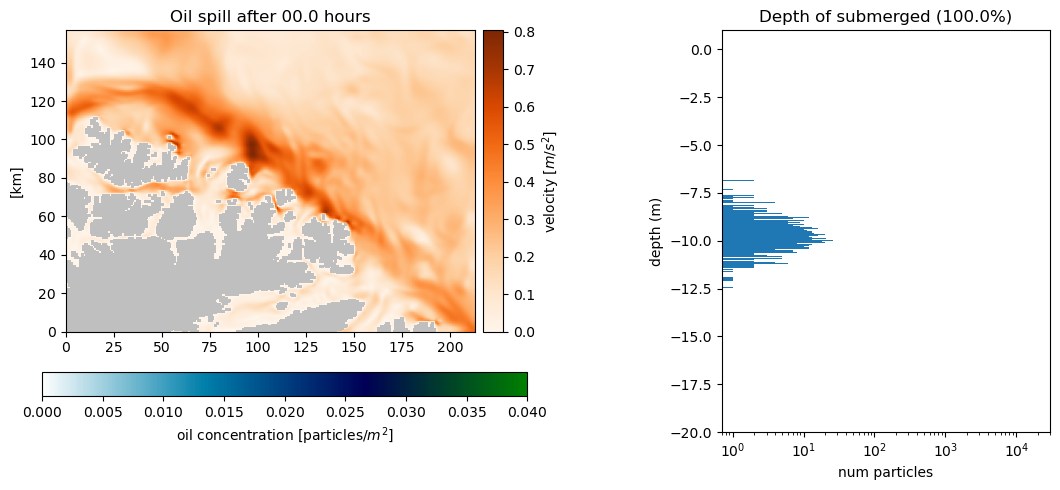

In [9]:
sim.step(60)
osph.plotOilWithVerticalDistribution(sim, oilspill_clim=[0, 0.04], max_depth=20, )

### Simulate

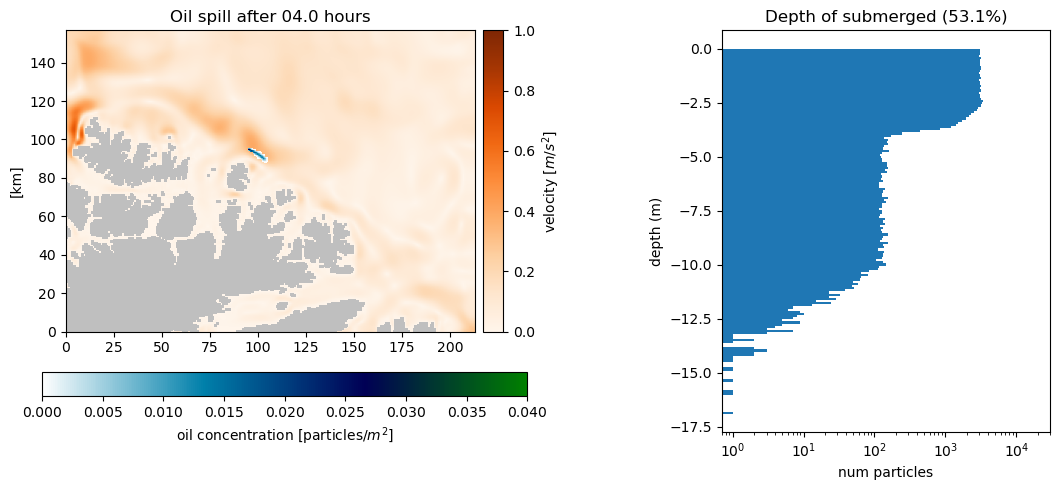

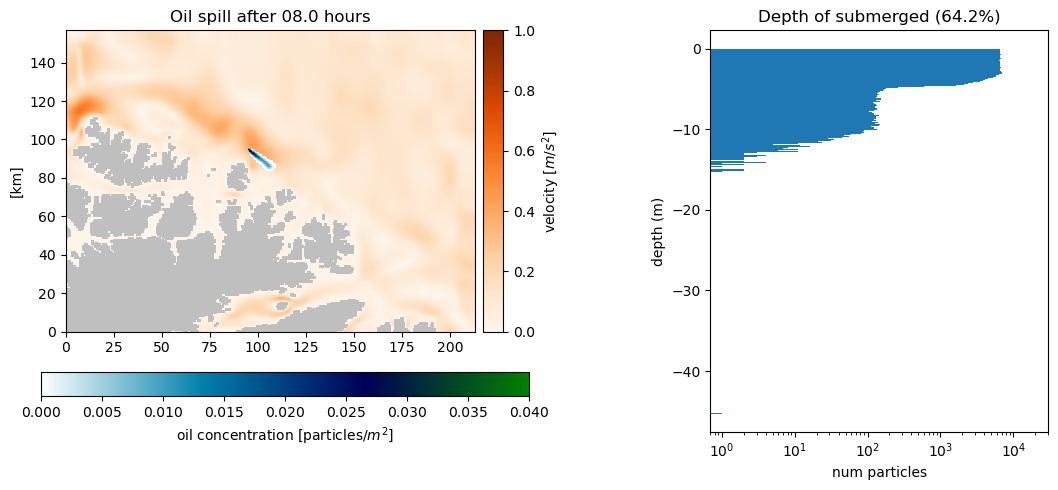

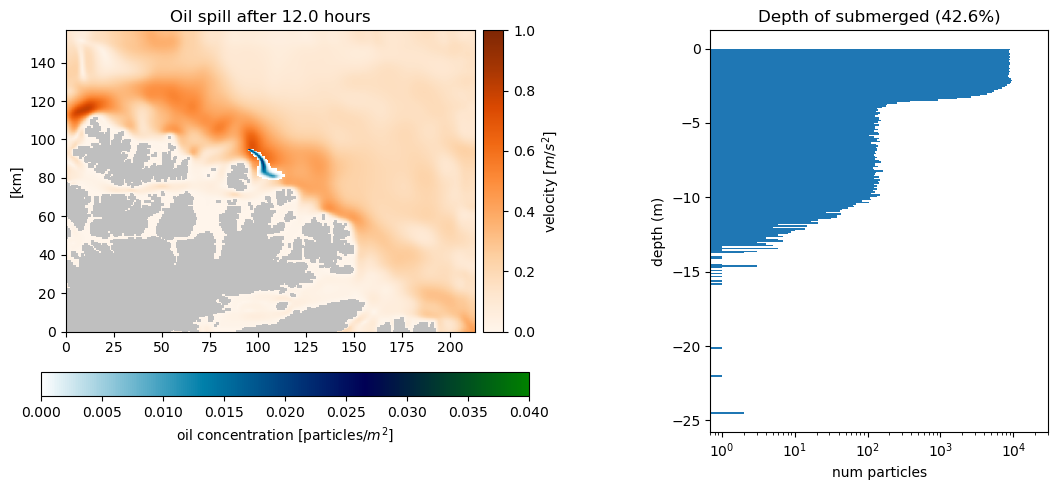

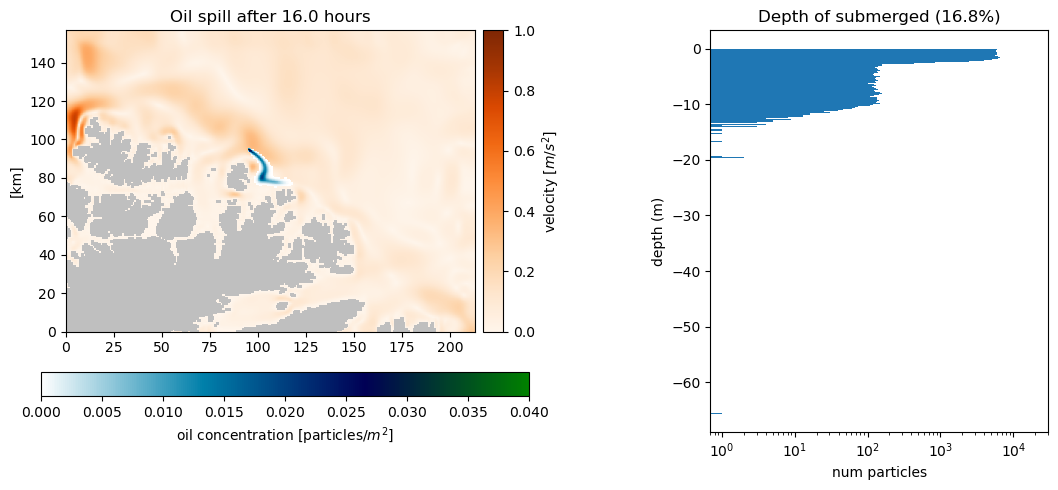

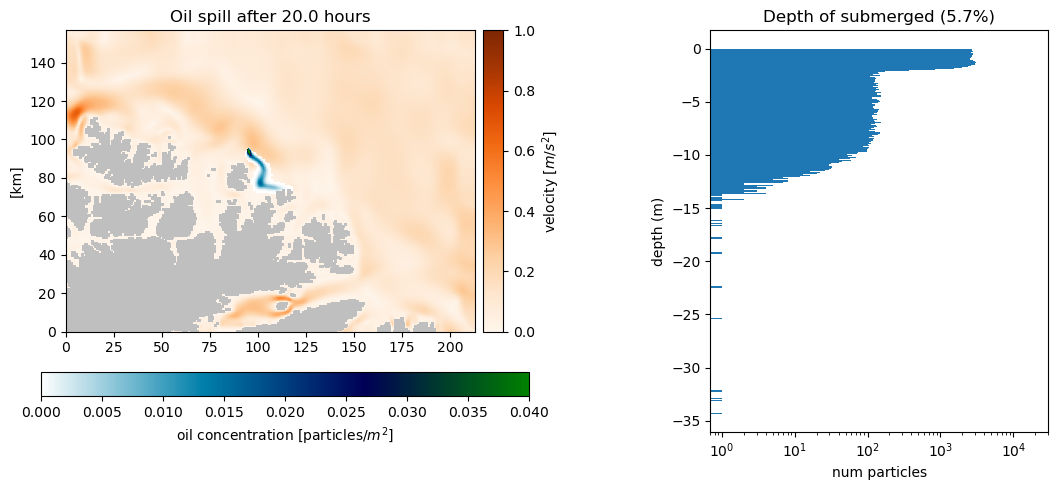

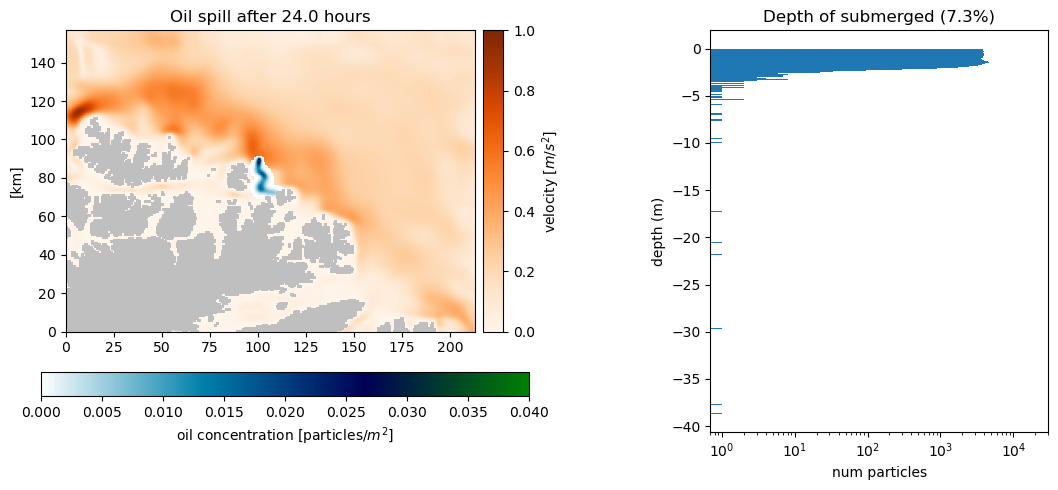

In [10]:
step_size = 4*3600
num_steps = 6
for i in range(num_steps):
    oilspill.sortParticlesFromSim(sim)
    sim.step(step_size)
    osph.plotOilWithVerticalDistribution(sim, vmax=1.0, oilspill_clim=[0, 0.04])
        


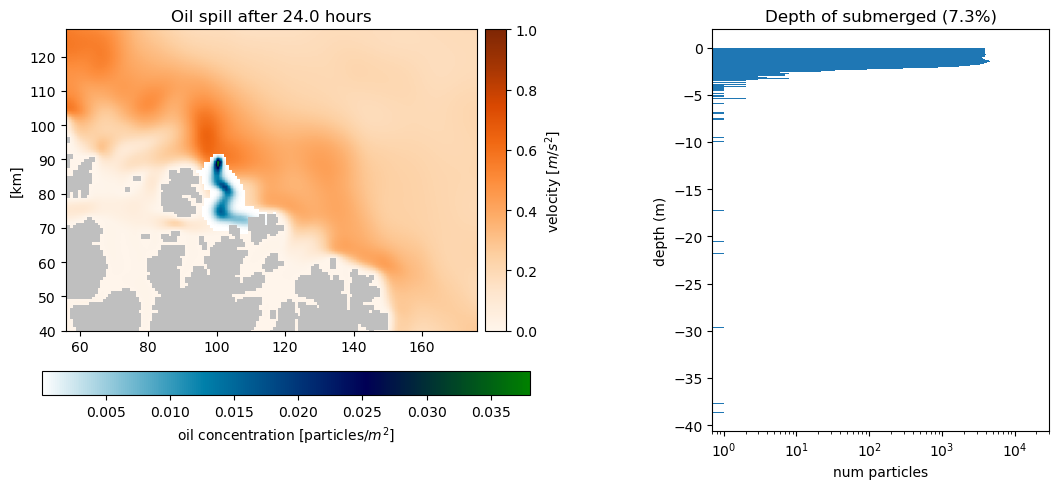

In [11]:
# Zoom on final release
zoomed_domain = [70, 220, 50, 160]
osph.plotOilWithVerticalDistribution(sim, domain=zoomed_domain, vmax=1.0)


## Check stranding

In [12]:
sum(oilspill.is_stranded())

21695

Text(0.5, 1.0, 'Stranded positions')

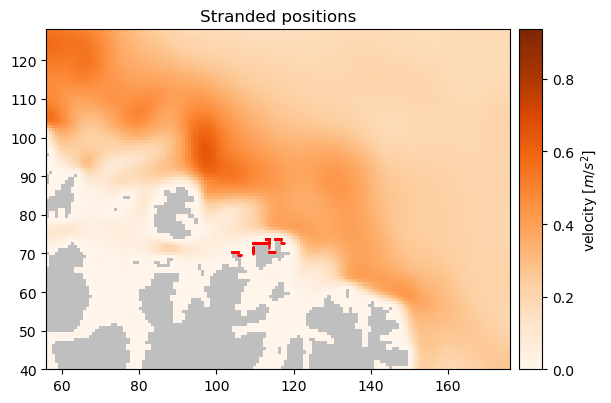

In [13]:
end_positions = sim.drifters.getDrifterPositions()
stranded_positions = end_positions[end_positions[:,2] > 999]

reload(DrifterPlotHelper)
ax = DrifterPlotHelper.background_from_sim(sim, drifter_domain=zoomed_domain)
ax.scatter(stranded_positions[:,0]/1000.0, stranded_positions[:,1]/1000.0, c="red", s=0.1, alpha=1, cmap='gray')
ax.set_title("Stranded positions")

# Rerun simulation with high resolution

In [14]:
highres_sim_args = NetCDFInitialization.rescaleInitialConditions(sim_args, 4)


In [15]:
if 'high_res_sim' in globals():
    high_res_sim.cleanUp()
if 'high_res_drifters' in globals():
    high_res_drifters.cleanUp()

# Create simulation object
high_res_sim = GPUOceanSim.GPUOceanSim(gpu_ctx, **NetCDFInitialization.removeMetadata(highres_sim_args))


reload(OilDrift)
# Define drifter object 
high_res_drifters = OilDrift.OilDrift(gpu_ctx, init_positions, **oil_args)
high_res_sim.attachDrifters(high_res_drifters)

This will give inaccurate coriolis along the border!
This will give inaccurate angle along the border!


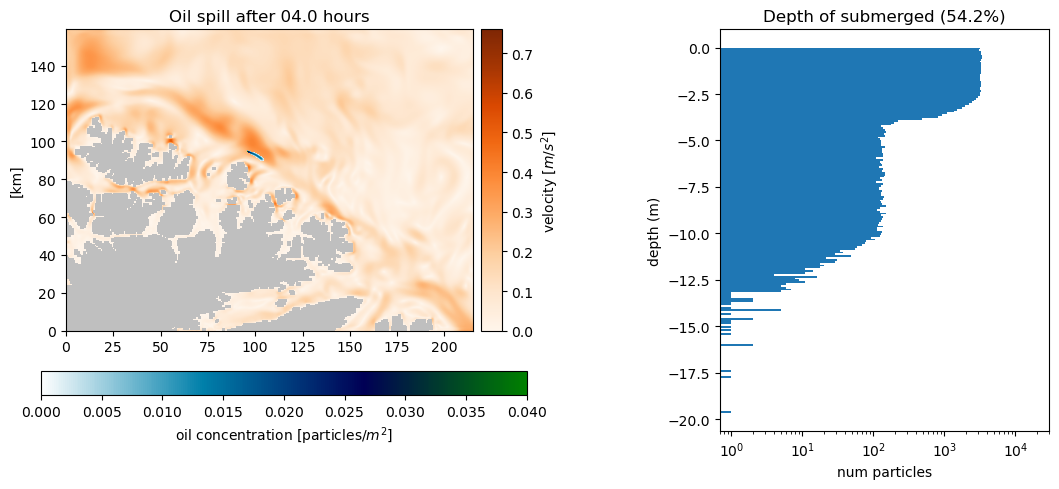

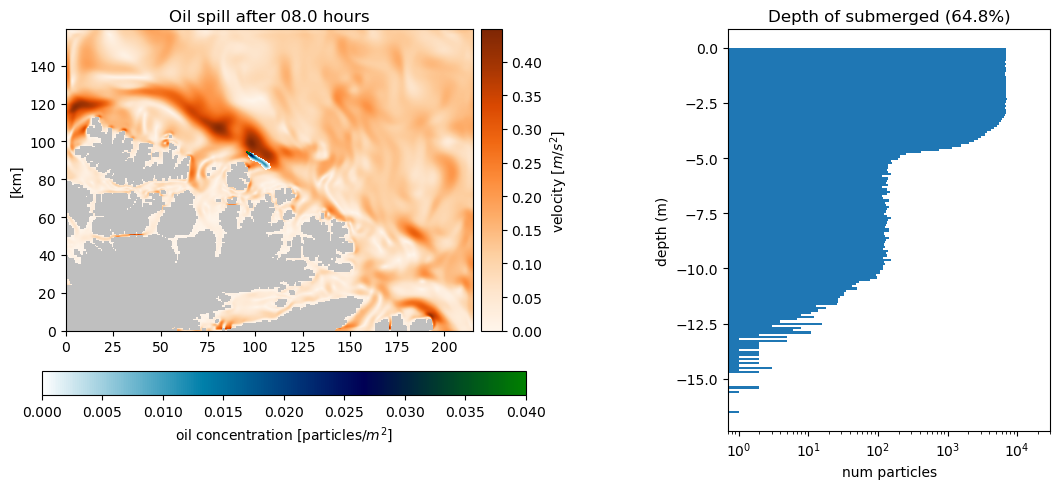

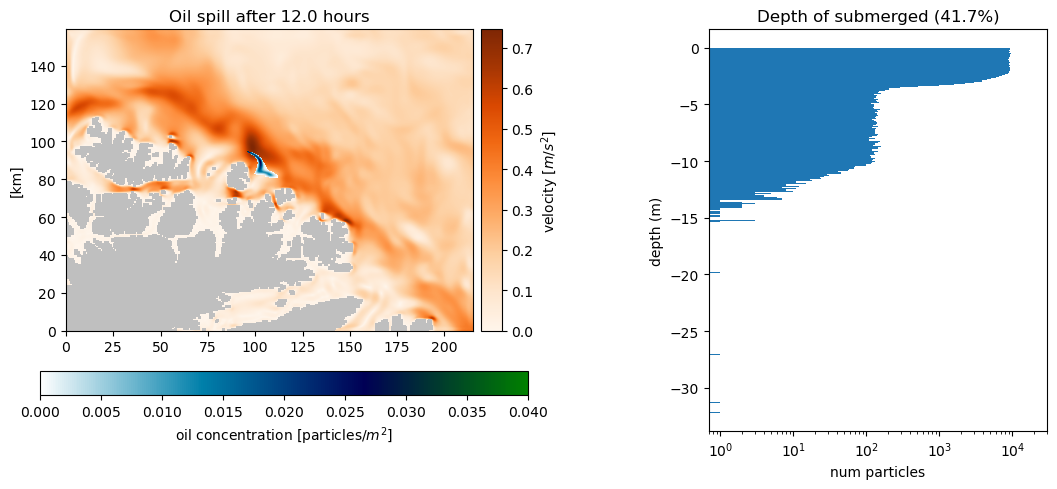

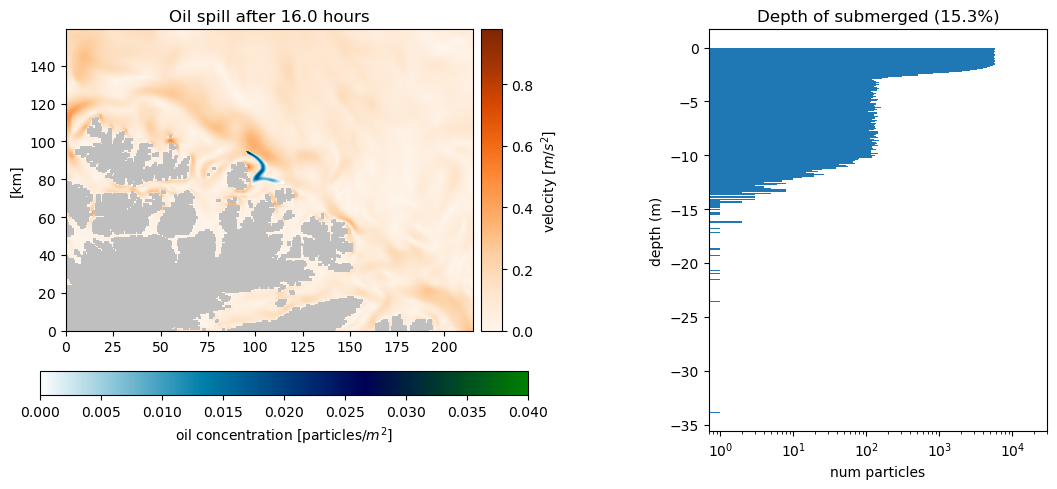

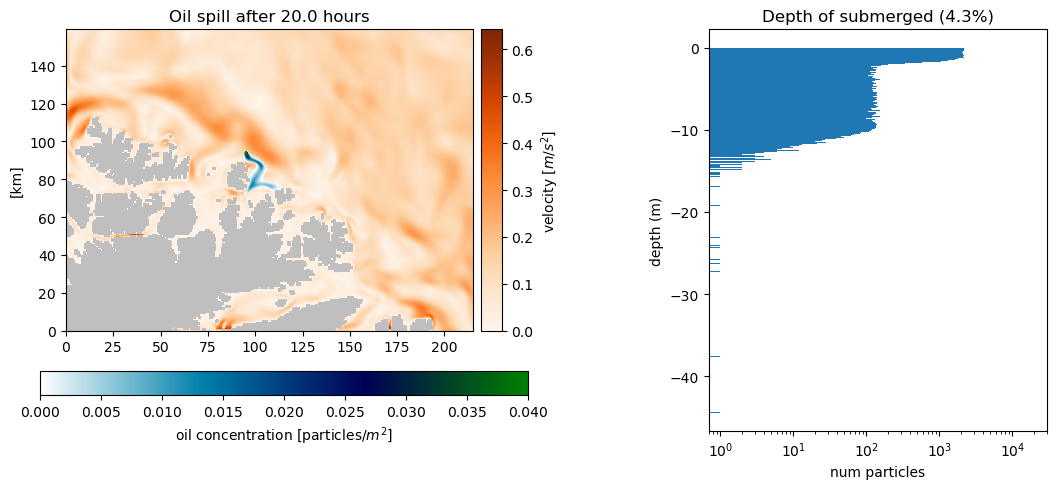

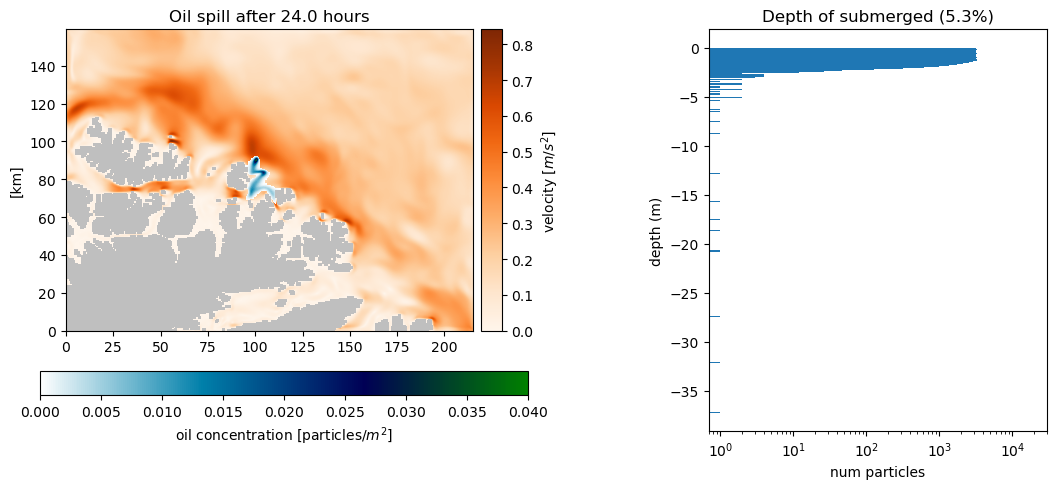

In [16]:
step_size = 4*3600
num_steps = 6
for i in range(num_steps):
    high_res_sim.updateDt()
    high_res_drifters.sortParticlesFromSim(high_res_sim)
    high_res_sim.step(step_size)
    osph.plotOilWithVerticalDistribution(high_res_sim, oilspill_clim=[0, 0.04])
        


## Compare 800 m and 200 m resolutions

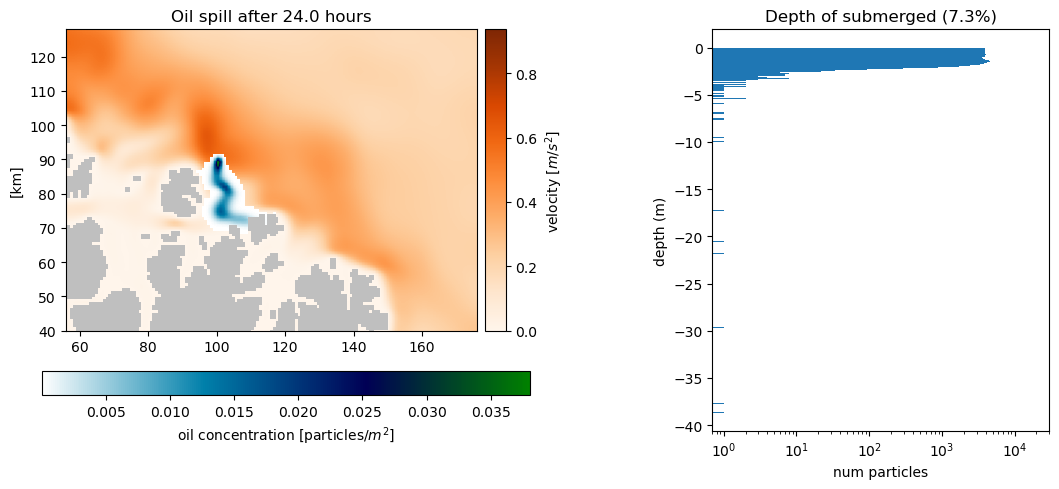

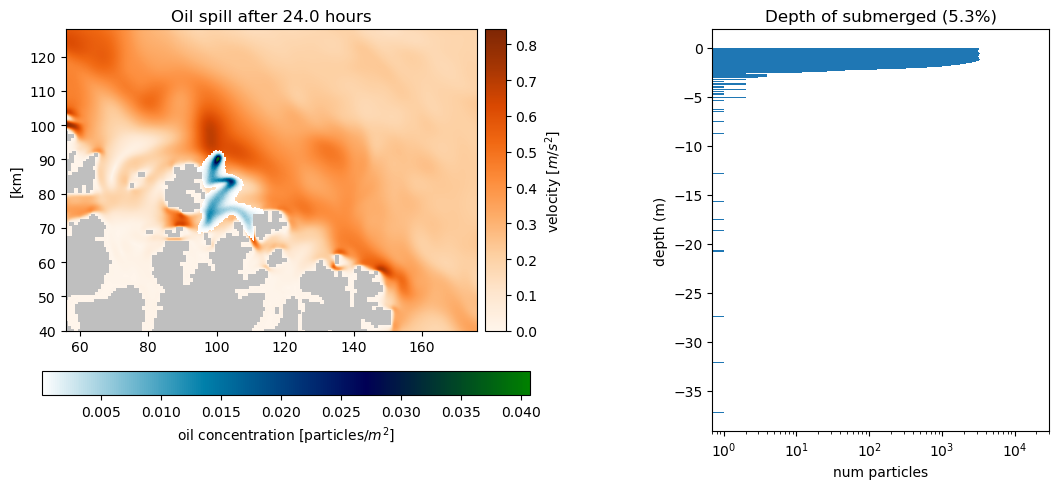

In [17]:
osph.plotOilWithVerticalDistribution(sim, domain=[70, 220, 50, 160])
osph.plotOilWithVerticalDistribution(high_res_sim, domain=np.array([70, 220, 50, 160])*4)


## Visualize stranding

[0. 2.]
[0. 1. 2.]


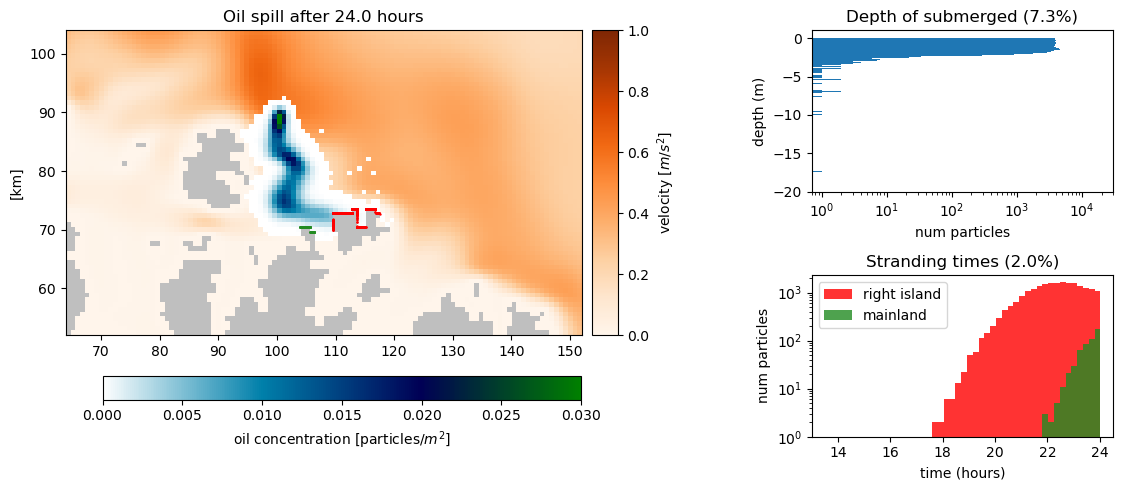

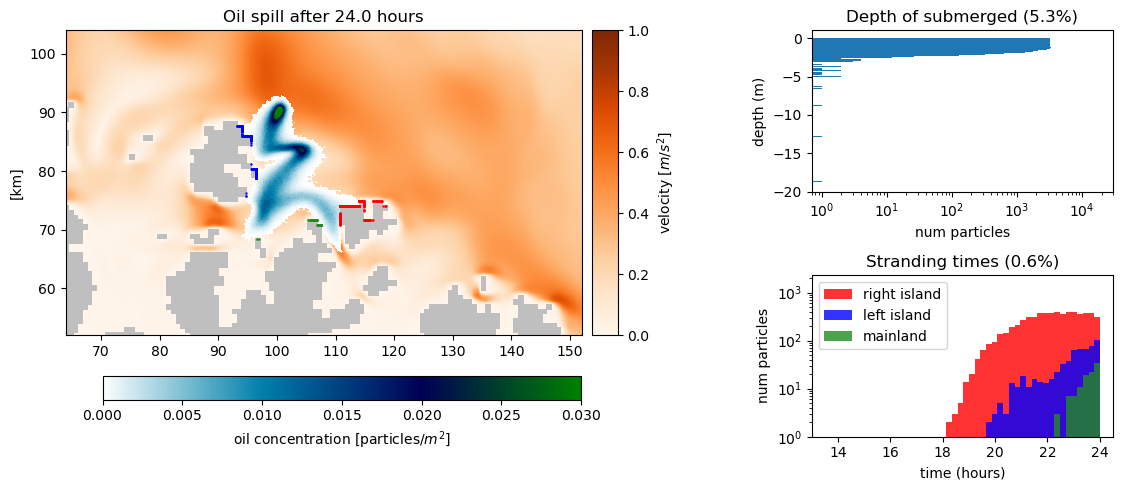

In [18]:
def stranded_classifier(pos):
    # 0 = right island
    # 1 = left island
    # 2 = mainland
    labels = ["right island", "left island", "mainland"]
    classification = np.ones(pos.shape[0])*2
    classification[np.logical_and(pos[:, 1] < 75000, pos[:,0] > 109200)] = 0
    classification[pos[:, 1] > 75000] = 1
    return classification, labels
reload(osph)
closer_domain = np.array([80, 190, 65, 130])
osph.plotOilWithVerticalDistribution(sim, domain=closer_domain, 
                                     vmax=1.0, max_depth=20, oilspill_clim=[0, 0.03],
                                     include_stranding=True, classifier=stranded_classifier, 
                                     stranding_start=13, hist_ymax=2300)
osph.plotOilWithVerticalDistribution(high_res_sim, domain=closer_domain*4, 
                                     vmax=1.0, max_depth=20, oilspill_clim=[0, 0.03],
                                     include_stranding=True, classifier=stranded_classifier, 
                                     stranding_start=13, hist_ymax=2300)


In [19]:

print("original num stranded: ", sum(oilspill.is_stranded()))
print("high res num stranded: ", sum(high_res_drifters.is_stranded()))

original num stranded:  21695
high res num stranded:  6677
